# Preprocessing for California Housing Prices Dataset
https://www.kaggle.com/datasets/camnugent/california-housing-prices/data

<b><u>The data contains the following housing information from the 1990 California census:</u></b>
1. longitude: A measure of how far west a house is; a higher value is farther west

2. latitude: A measure of how far north a house is; a higher value is farther north

3. housingMedianAge: Median age of a house within a block; a lower number is a newer building

4. totalRooms: Total number of rooms within a block

5. totalBedrooms: Total number of bedrooms within a block

6. population: Total number of people residing within a block

7. households: Total number of households, a group of people residing within a home unit, for a block

8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)

9. medianHouseValue: Median house value for households within a block (measured in US Dollars)

10. oceanProximity: Location of the house w.r.t ocean/sea

In [163]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

## Data Exploration

In [164]:
df = pd.read_csv('./housing.csv', sep = ',')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [165]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [166]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [167]:
df.corr(numeric_only = True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069608,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066983,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.320451,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.930380,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069608,-0.066983,-0.320451,0.930380,1.000000,0.877747,0.979728,-0.007723,0.049686
population,0.099773,-0.108785,-0.296244,0.857126,0.877747,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.979728,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007723,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049686,-0.024650,0.065843,0.688075,1.000000


In [168]:
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [169]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

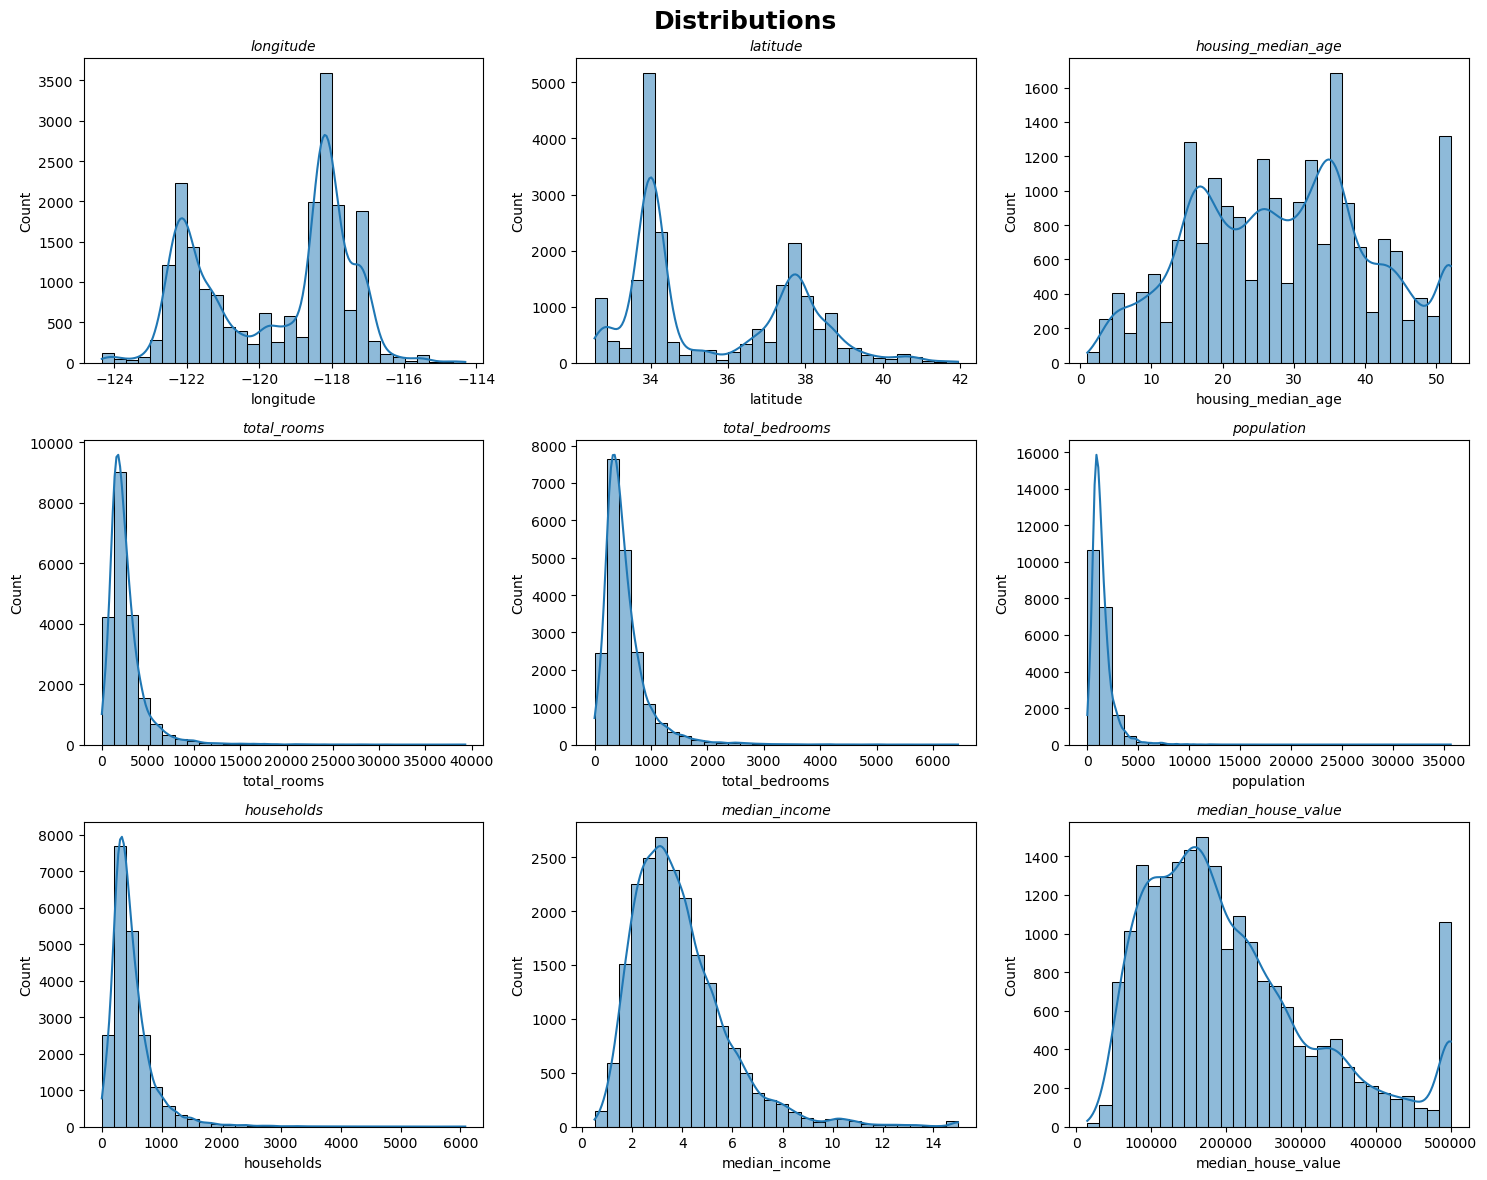

In [170]:
# Code inspired by Furkan Sayar's plot on Kaggle for this dataset

non_cat_columns = df.select_dtypes(exclude = ['object', 'category'])

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (15, 12))
fig.suptitle('Distributions', fontsize = 18, fontweight = 'bold')

for i, col in enumerate(non_cat_columns):
    row_idx = i // 3
    col_idx = i % 3
    ax = axes[row_idx, col_idx]
    sns.histplot(data = df, x = col, kde = True, ax = ax, bins = 30)
    ax.set_title(col, fontsize = 10, fontstyle = 'italic')

plt.tight_layout()
plt.show()

## Data Modifications

Since `totalBedrooms` is the only column with nulls, we can either impute with the median or drop these rows. In order to conserve the size of the dataset, we have opted for median imputation:

In [171]:
bedrooms_median = df['total_bedrooms'].median()
print(bedrooms_median)

435.0


In [172]:
df['total_bedrooms'] = df['total_bedrooms'].fillna(bedrooms_median)

In [173]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Next, we shall deal with the nominal variable, `ocean_proximity`, using one-hot encoding. While encoding, we shall drop one categorical column to avoid multicollinearity (highly correlated independent variables) during linear regression.

In [174]:
categorical_columns = df.select_dtypes(include=['object']).columns.tolist() 
print(categorical_columns)

encoder = OneHotEncoder(sparse_output = False, drop = 'first')
one_hot_encoded = encoder.fit_transform(df[categorical_columns])

raw_names = encoder.get_feature_names_out(categorical_columns).tolist()
cleaned_names = [name.removeprefix('ocean_proximity_').lower().replace(' ', '_') for name in raw_names]

encoded_df = pd.DataFrame(one_hot_encoded, columns = cleaned_names, index = df.index)

df_encoded = pd.concat([df, encoded_df], axis = 1).drop(categorical_columns, axis = 1)

['ocean_proximity']


In [175]:
df_encoded.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,inland,island,near_bay,near_ocean
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0.0,0.0,1.0,0.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0.0,0.0,1.0,0.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0.0,0.0,1.0,0.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0.0,0.0,1.0,0.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0.0,0.0,1.0,0.0


Next, we shall do feature engineering. The columns `[total_rooms, total_bedrooms, population]` are block-level aggregates, which makes them hard to compare across blocks of different size. They are also linearly dependent. So, using ratios derived from these columns would be more informative and avoid multicollinearity.

In [176]:
df_encoded['rooms_per_household'] = df_encoded['total_rooms'] / df_encoded['households']
df_encoded['bedrooms_per_room'] = df_encoded['total_bedrooms'] / df_encoded['total_rooms']
df_encoded['population_per_household'] = df_encoded['population'] / df_encoded['households']

df_encoded = df_encoded.drop(columns = ['total_rooms', 'total_bedrooms', 'population'])
df_encoded.head()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,inland,island,near_bay,near_ocean,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,126.0,8.3252,452600.0,0.0,0.0,1.0,0.0,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,1138.0,8.3014,358500.0,0.0,0.0,1.0,0.0,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,177.0,7.2574,352100.0,0.0,0.0,1.0,0.0,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,219.0,5.6431,341300.0,0.0,0.0,1.0,0.0,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,259.0,3.8462,342200.0,0.0,0.0,1.0,0.0,6.281853,0.172096,2.181467


As seen from the Distributions plot earlier, `median_house_value` has a hard cap at $500,001, causing many records to cluster at exactly that value. Since these are a result of the cap and not true observation, we will remove them.

In [177]:
df_cleaned = df_encoded[df_encoded['median_house_value'] < 500_001].copy()
print(f'Used to have {len(df_encoded)} rows and now have {len(df_cleaned)} (removed {len(df_encoded) - len(df_cleaned)} rows of data).')

Used to have 20640 rows and now have 19675 (removed 965 rows of data).


We will do a stratified split based on `medianIncome` because it is the strongest predictor. This avoids over- or under-representation of high-income districts in one set.

In [178]:
df_cleaned['bin'] = pd.qcut(df_cleaned['median_income'], q = 5, labels = False)
df_cleaned['bin'].value_counts()

bin
0    3936
4    3935
2    3935
3    3935
1    3934
Name: count, dtype: int64

## Train/Test Split

In [179]:
train_df, test_df = train_test_split(df_cleaned, test_size = 0.2, random_state = 42, stratify = df_cleaned['bin'])

train_df = train_df.drop(['bin'], axis = 1)
test_df = test_df.drop(['bin'], axis = 1)

In [180]:
train_df.head()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,inland,island,near_bay,near_ocean,rooms_per_household,bedrooms_per_room,population_per_household
18507,-122.01,36.99,29.0,41.0,6.4469,271400.0,0.0,0.0,0.0,1.0,5.536585,0.198238,2.731707
4662,-118.30,34.05,42.0,545.0,1.7210,214300.0,0.0,0.0,0.0,0.0,2.708257,0.413279,2.944954
16344,-121.33,38.04,10.0,209.0,5.1878,153900.0,1.0,0.0,0.0,0.0,6.799043,0.143561,3.143541
16071,-122.49,37.75,43.0,378.0,3.9205,319100.0,0.0,0.0,0.0,1.0,5.407407,0.192270,2.589947
4769,-118.35,34.04,41.0,375.0,2.4635,169400.0,0.0,0.0,0.0,0.0,4.312000,0.261596,2.960000


In [181]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15740 entries, 18507 to 1195
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 15740 non-null  float64
 1   latitude                  15740 non-null  float64
 2   housing_median_age        15740 non-null  float64
 3   households                15740 non-null  float64
 4   median_income             15740 non-null  float64
 5   median_house_value        15740 non-null  float64
 6   inland                    15740 non-null  float64
 7   island                    15740 non-null  float64
 8   near_bay                  15740 non-null  float64
 9   near_ocean                15740 non-null  float64
 10  rooms_per_household       15740 non-null  float64
 11  bedrooms_per_room         15740 non-null  float64
 12  population_per_household  15740 non-null  float64
dtypes: float64(13)
memory usage: 1.7 MB


In [182]:
test_df.head()

,longitude,latitude,housing_median_age,households,median_income,median_house_value,inland,island,near_bay,near_ocean,rooms_per_household,bedrooms_per_room,population_per_household
16296,-121.22,37.97,37.0,337.0,2.4010,58400.0,1.0,0.0,0.0,0.0,4.492582,0.222589,3.326409
11235,-117.96,33.81,35.0,208.0,5.2384,177400.0,0.0,0.0,0.0,0.0,5.543269,0.166522,4.250000
20366,-118.92,34.17,17.0,244.0,5.9836,294800.0,0.0,0.0,0.0,0.0,6.360656,0.158505,2.807377
20008,-119.06,36.15,20.0,247.0,1.6354,49000.0,1.0,0.0,0.0,0.0,5.190283,0.212949,3.449393
18762,-122.25,40.66,15.0,505.0,3.6413,108500.0,1.0,0.0,0.0,0.0,5.487129,0.197041,2.817822


In [183]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3935 entries, 16296 to 2015
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 3935 non-null   float64
 1   latitude                  3935 non-null   float64
 2   housing_median_age        3935 non-null   float64
 3   households                3935 non-null   float64
 4   median_income             3935 non-null   float64
 5   median_house_value        3935 non-null   float64
 6   inland                    3935 non-null   float64
 7   island                    3935 non-null   float64
 8   near_bay                  3935 non-null   float64
 9   near_ocean                3935 non-null   float64
 10  rooms_per_household       3935 non-null   float64
 11  bedrooms_per_room         3935 non-null   float64
 12  population_per_household  3935 non-null   float64
dtypes: float64(13)
memory usage: 430.4 KB


In [184]:
train_df.to_csv('train.csv', index = False)
test_df.to_csv('test.csv', index = False)